In [ ]:
# Random forest Regressor 

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Core libraries for data manipulation and analysis
import pandas as pd
import numpy as np

# Libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn for preprocessing
from sklearn.preprocessing import MinMaxScaler

# TensorFlow and Keras for building the LSTM model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout

# KerasTuner for hyperparameter optimization

sns.set(style='whitegrid')
plt.style.use('seaborn-v0_8-pastel')

print("Libraries imported successfully!")

Libraries imported successfully!


In [21]:
train_path = '/kaggle/input/nasa-cmaps/CMaps/train_FD001.txt'
test_path = '/kaggle/input/nasa-cmaps/CMaps/test_FD001.txt'
rul_path = '/kaggle/input/nasa-cmaps/CMaps/RUL_FD001.txt'



train_df = pd.read_csv(r"C:\Users\dalmy\Downloads\train_FD001.txt", sep=r'\s+', header=None, names=columns)
test_df = pd.read_csv(r"C:\Users\dalmy\Downloads\test_FD001.txt", sep=r'\s+', header=None, names=columns)
truth_df = pd.read_csv(r"C:\Users\dalmy\Downloads\RUL_FD001.txt", sep=r'\s+', header=None, names=['RUL'])

print("Data loaded successfully!")

Data loaded successfully!


In [22]:
train_df.drop(columns=[26, 27], inplace=True, errors='ignore')
test_df.drop(columns=[26, 27], inplace=True, errors='ignore')

# Define descriptive column names
column_names = [
    'engine_id', 'time_in_cycles', 'setting_1', 'setting_2', 'setting_3',
    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
    'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12',
    'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18',
    'sensor_19', 'sensor_20', 'sensor_21'
]

# Assign the column names to the train and test dataframes
train_df.columns = column_names
test_df.columns = column_names

# FIX: Drop the extra empty column from the ground truth data
truth_df.drop(columns=[1], inplace=True, errors='ignore')

In [23]:
stats = train_df.describe().transpose()
constant_cols = stats[stats['std'] == 0].index.tolist()

# Identify columns with near-zero correlation to RUL from previous analysis
low_corr_cols = ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16']

# Combine the lists of columns to drop
cols_to_drop = list(set(constant_cols + low_corr_cols))

# Drop these columns from both the training and test sets
train_df.drop(columns=cols_to_drop, inplace=True)
test_df.drop(columns=cols_to_drop, inplace=True)

print(f"Dropped the following uninformative columns: {cols_to_drop}")

Dropped the following uninformative columns: ['sensor_5', 'sensor_16', 'sensor_1', 'sensor_18', 'setting_3', 'sensor_10', 'sensor_19']


In [25]:
max_cycles_df = train_df.groupby('engine_id')['time_in_cycles'].max().reset_index()
max_cycles_df.columns = ['engine_id', 'max_cycles']

# Merge the max cycle information back into the training dataframe
train_df = pd.merge(train_df, max_cycles_df, on='engine_id', how='left')

# Calculate RUL for each row
train_df['RUL'] = train_df['max_cycles'] - train_df['time_in_cycles']

# Drop the 'max_cycles' column as it's no longer needed for training
train_df.drop(columns=['max_cycles'], inplace=True)

print("RUL column calculated and added to the training data.")

RUL column calculated and added to the training data.


In [26]:
scaler = MinMaxScaler()

# Dynamically select the feature columns to be scaled
# These are all columns except the identifiers and the target variable
feature_cols = train_df.columns.drop(['engine_id', 'time_in_cycles', 'RUL']).tolist()

# Fit the scaler on the training data and transform it
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])

# Transform the test data using the same fitted scaler
test_df[feature_cols] = scaler.transform(test_df[feature_cols])

print("Feature scaling applied successfully to both train and test sets.")

Feature scaling applied successfully to both train and test sets.


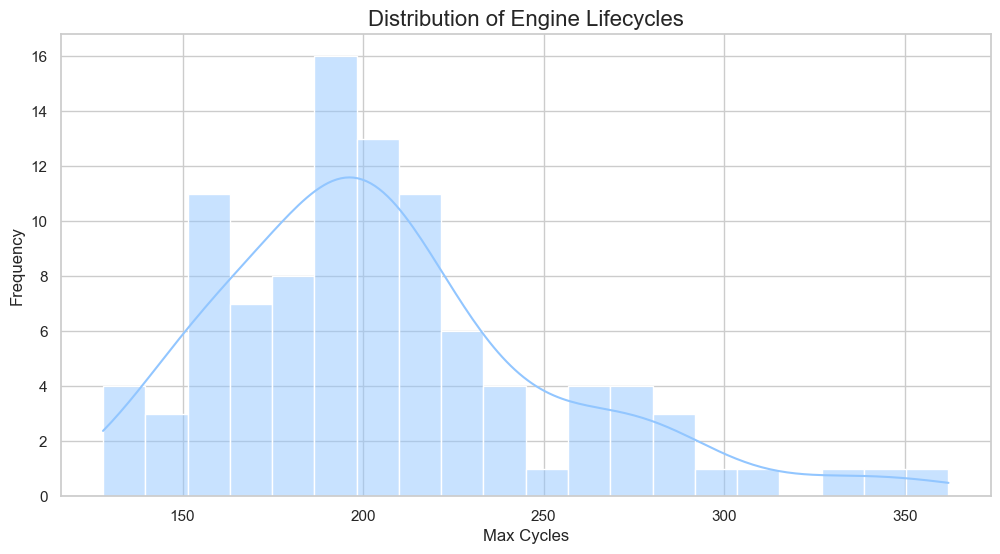

In [31]:
plt.figure(figsize=(12, 6))

# Plot the distribution of max cycles
sns.histplot(max_cycles_df['max_cycles'], bins=20, kde=True)

plt.title('Distribution of Engine Lifecycles', fontsize=16)
plt.xlabel('Max Cycles')
plt.ylabel('Frequency')
plt.show()

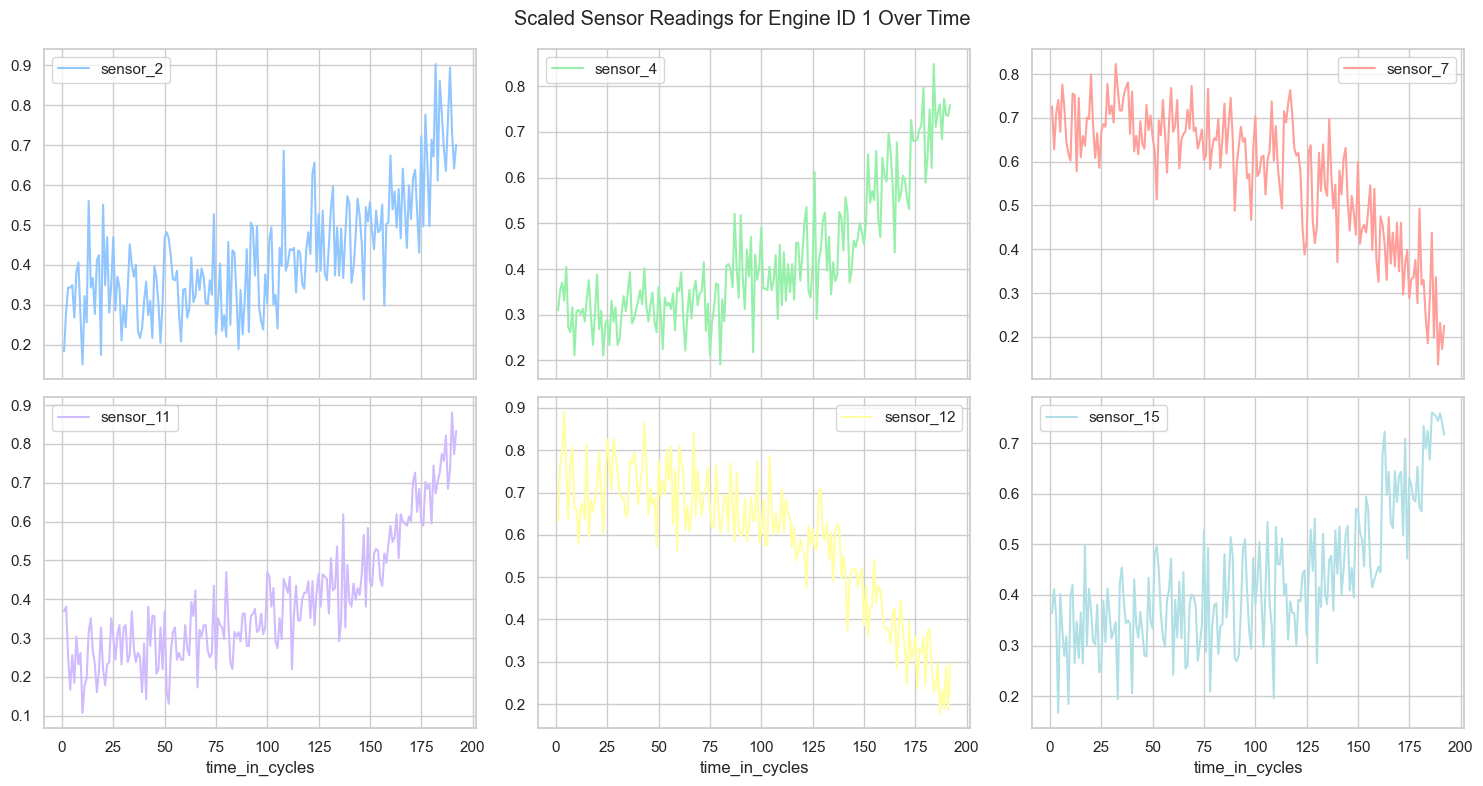

In [32]:
engine_to_plot = train_df[train_df['engine_id'] == 1]

# Define some of the highly-correlated sensors that remain in our dataset
sensors_to_plot = ['sensor_2', 'sensor_4', 'sensor_7', 'sensor_11', 'sensor_12', 'sensor_15']

# Create the plot
engine_to_plot.plot(x='time_in_cycles', y=sensors_to_plot, subplots=True, layout=(2, 3), figsize=(15, 8), title='Scaled Sensor Readings for Engine ID 1 Over Time')
plt.tight_layout()
plt.show()

In [27]:
from sklearn.model_selection import train_test_split

# Define the features (X) and target (y)
features = train_df.columns.drop(['engine_id', 'time_in_cycles', 'RUL'])
X = train_df[features]
y = train_df['RUL']

# Split the data into training and validation sets
# We'll use 80% for training and 20% for validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Validation features shape: {X_val.shape}")

Training features shape: (16504, 17)
Validation features shape: (4127, 17)


In [28]:
from sklearn.ensemble import RandomForestRegressor

# Instantiate the Random Forest Regressor model
# n_estimators is the number of trees in the forest.
# n_jobs=-1 allows the model to use all available CPU cores for faster training.
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model
print("Training the Random Forest model...")
rf_model.fit(X_train, y_train)
print("Training complete.")

Training the Random Forest model...
Training complete.


In [30]:
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions on the validation set
y_pred_val = rf_model.predict(X_val)

# Calculate the Root Mean Squared Error (RMSE)
rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
print(f"Validation RMSE: {rmse_val:.2f}")

# Calculate the R-squared (R2) Score


Validation RMSE: 41.47


In [17]:
# Lstm 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

columns = ['unit_id', 'time_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + \
          [f'sensor_{i}' for i in range(1, 22)]

# DATA_PATH = os.path.join(os.path.dirname(__file__), '..', 'data')
# OUTPUT_PATH = os.path.join(DATA_PATH, 'exploration')
# os.makedirs(OUTPUT_PATH, exist_ok=True)


train = pd.read_csv(r"C:\Users\dalmy\Downloads\train_FD001.txt", sep=r'\s+', header=None, names=columns)
test = pd.read_csv(r"C:\Users\dalmy\Downloads\test_FD001.txt", sep=r'\s+', header=None, names=columns)
rul_test = pd.read_csv(r"C:\Users\dalmy\Downloads\RUL_FD001.txt", sep=r'\s+', header=None, names=['RUL'])

# Create RUL labels for training data
train['RUL'] = train.groupby('unit_id')['time_cycles'].transform(lambda x: x.max() - x)

# Basic stats
print(f"\nTraining: {train.shape[0]} rows, {train['unit_id'].nunique()} engines")
print(f"Test: {test.shape[0]} rows, {test['unit_id'].nunique()} engines")
print(f"Sensors: {len([c for c in columns if 'sensor' in c])}")

# Engine lifetimes
lifetimes = train.groupby('unit_id')['time_cycles'].max()
print(f"\nEngine lifetime: min={lifetimes.min()}, max={lifetimes.max()}, avg={lifetimes.mean():.1f} cycles")




Training: 20631 rows, 100 engines
Test: 13096 rows, 100 engines
Sensors: 21

Engine lifetime: min=128, max=362, avg=206.3 cycles


In [3]:
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import plotly.graph_objs as go
import numpy as np
import pandas as pd
from tensorflow import keras
import os

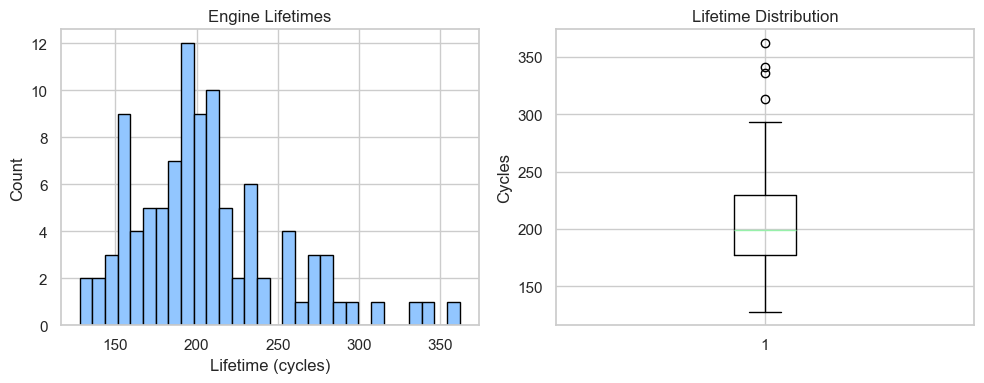

In [4]:
# Engine lifetimes
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(lifetimes, bins=30, edgecolor='black')
plt.xlabel('Lifetime (cycles)')
plt.ylabel('Count')
plt.title('Engine Lifetimes')

plt.subplot(1, 2, 2)
plt.boxplot(lifetimes)
plt.ylabel('Cycles')
plt.title('Lifetime Distribution')
plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_PATH, 'lifetimes.png'), dpi=100)

# Sensor degradation for engine #1


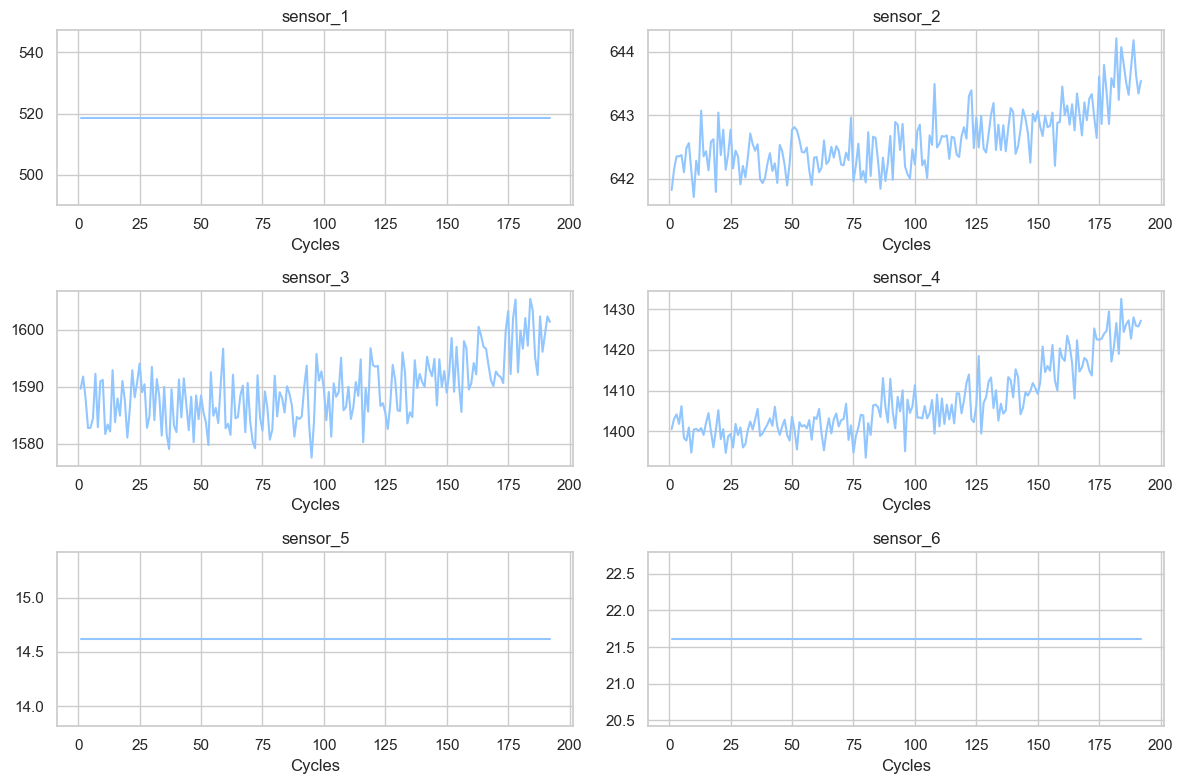

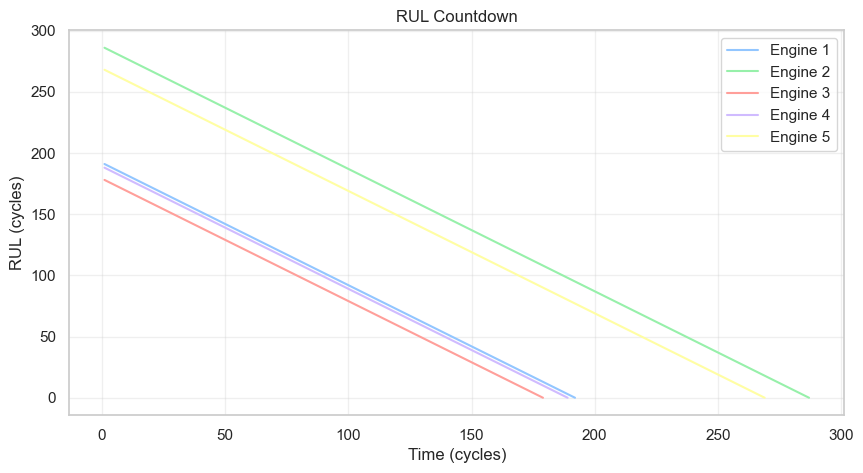

In [5]:
sensor_cols = [c for c in columns if 'sensor' in c]
engine1 = train[train['unit_id'] == 1]

fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()
for i in range(6):
    axes[i].plot(engine1['time_cycles'], engine1[sensor_cols[i]])
    axes[i].set_title(sensor_cols[i])
    axes[i].set_xlabel('Cycles')
plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_PATH, 'sensors.png'), dpi=100)

# RUL countdown
plt.figure(figsize=(10, 5))
for i in range(1, 6):
    eng = train[train['unit_id'] == i]
    plt.plot(eng['time_cycles'], eng['RUL'], label=f'Engine {i}')
plt.xlabel('Time (cycles)')
plt.ylabel('RUL (cycles)')
plt.title('RUL Countdown')
plt.legend()
plt.grid(True, alpha=0.3)

In [6]:
from sklearn.preprocessing import MinMaxScaler
import joblib
import os
import numpy as np

train['RUL'] = train.groupby('unit_id')['time_cycles'].transform(lambda x: x.max() - x)

# Drop constant sensors (variance < 0.01)
sensor_cols = [c for c in columns if 'sensor' in c]
variances = train[sensor_cols].var()
drop_sensors = variances[variances < 0.01].index.tolist()
print(f"Dropping {len(drop_sensors)} constant sensors: {drop_sensors}")

# Keep useful features
feature_cols = ['op_setting_1', 'op_setting_2', 'op_setting_3'] + \
               [s for s in sensor_cols if s not in drop_sensors]
print(f"Using {len(feature_cols)} features")

# Normalize features (0-1)
scaler = MinMaxScaler()
train[feature_cols] = scaler.fit_transform(train[feature_cols])
test[feature_cols] = scaler.transform(test[feature_cols])

# Save scaler
# joblib.dump(scaler, os.path.join(OUTPUT_PATH, 'scaler.pkl'))

# Create sequences for LSTM (window size = 30 cycles)
SEQUENCE_LENGTH = 30

def create_sequences(df, seq_len):
    sequences = []
    targets = []

    for unit_id in df['unit_id'].unique():
        engine_data = df[df['unit_id'] == unit_id]
        features = engine_data[feature_cols].values
        rul_values = engine_data['RUL'].values

        for i in range(len(features) - seq_len + 1):
            sequences.append(features[i:i+seq_len])
            targets.append(rul_values[i+seq_len-1])

    return np.array(sequences), np.array(targets)

X_train, y_train = create_sequences(train, SEQUENCE_LENGTH)
print(f"Train: {X_train.shape}, {y_train.shape}")

# For test data, use last sequence of each engine
X_test = []
y_test = rul_test['RUL'].values

for unit_id in test['unit_id'].unique():
    engine_data = test[test['unit_id'] == unit_id]
    features = engine_data[feature_cols].values

    # Pad if less than sequence length
    if len(features) < SEQUENCE_LENGTH:
        pad = np.zeros((SEQUENCE_LENGTH - len(features), len(feature_cols)))
        features = np.vstack([pad, features])

    X_test.append(features[-SEQUENCE_LENGTH:])

X_test = np.array(X_test)
print(f"Test: {X_test.shape}, {y_test.shape}")

Dropping 10 constant sensors: ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_8', 'sensor_10', 'sensor_13', 'sensor_15', 'sensor_16', 'sensor_18', 'sensor_19']
Using 14 features
Train: (17731, 30, 14), (17731,)
Test: (100, 30, 14), (100,)


In [7]:
import sys
import subprocess

subprocess.check_call([sys.executable, "-m", "pip", "install", "dash"])



0

In [8]:
import sys
import subprocess

def install_package(package_name):
    """Install a Python package using the same Python interpreter."""
    subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

# Install Dash
install_package("dash")

# Install TensorFlow
install_package("tensorflow")

print("✅ Dash and TensorFlow have been installed successfully!")

✅ Dash and TensorFlow have been installed successfully!


X_train: (17731, 30, 14)
y_train: (17731,)
X_test: (100, 30, 14)
y_test: (100,)


C:\Users\dalmy\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 30, 64)              │          20,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 30, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 33,185 (129.63 KB)

 Trainable params: 33,185 (129.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 18s 98ms/step - loss: 10709.8096 - mae: 85.4503 - val_loss: 13966.2314 - val_mae: 94.5575
Epoch 2/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 19s 87ms/step - loss: 8327.5303 - mae: 72.5973 - val_loss: 10683.1602 - val_mae: 79.7674
Epoch 3/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 11s 89ms/step - loss: 5737.8677 - mae: 58.8696 - val_loss: 7709.5625 - val_mae: 67.0649
Epoch 4/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - loss: 4115.7812 - mae: 50.7397 - val_loss: 6120.5288 - val_mae: 60.9697
Epoch 5/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - loss: 3608.9963 - mae: 48.6820 - val_loss: 5612.1816 - val_mae: 59.3884
Epoch 6/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 11s 85ms/step - loss: 3533.1797 - mae: 48.6063 - val_loss: 5463.5981 - val_mae: 59.0377
Epoch 7/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - loss: 3520.0479 - mae: 48.5909 - val_loss: 5453.6714 - val_mae: 59.0179
Epoch 8/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - loss: 3513.8552 - mae: 48.6671 - val_loss: 546

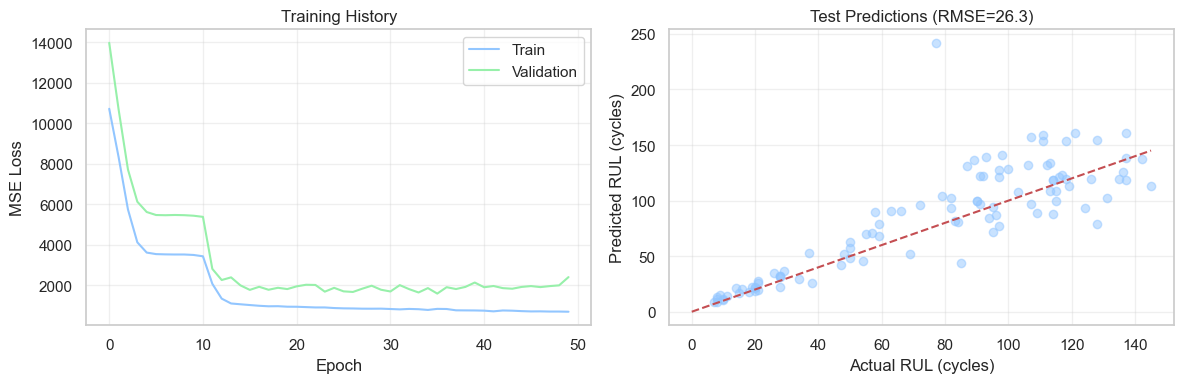

In [9]:
import os
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

model = keras.Sequential([
    layers.LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=128,
    verbose=1
)

# model.save(os.path.join(OUTPUT_PATH, 'lstm_model.keras'))

y_pred_train = model.predict(X_train).flatten()
y_pred_test = model.predict(X_test).flatten()
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"\nTrain RMSE: {rmse_train:.2f} cycles")
print(f"Test RMSE: {rmse_test:.2f} cycles")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training History')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([0, y_test.max()], [0, y_test.max()], 'r--')
plt.xlabel('Actual RUL (cycles)')
plt.ylabel('Predicted RUL (cycles)')
plt.title(f'Test Predictions (RMSE={rmse_test:.1f})')
plt.grid(True, alpha=0.3)

plt.tight_layout()

In [10]:
 import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import plotly.graph_objs as go
import numpy as np
import pandas as pd
from tensorflow import keras
import os

In [11]:
 import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import plotly.graph_objs as go
import numpy as np
import pandas as pd
from tensorflow import keras
import os

# DATA_PATH = os.path.join(os.path.dirname(__file__), '..', 'data')
# model = keras.models.load_model(os.path.join(DATA_PATH, 'models', 'lstm_model.keras'))

# X_test = np.load(os.path.join(DATA_PATH, 'processed', 'X_test.npy'))
# y_test = np.load(os.path.join(DATA_PATH, 'processed', 'y_test.npy'))
y_pred = model.predict(X_test).flatten()

# Calculate risk levels
def get_risk_status(rul):
    if rul < 30:
        return 'CRITICAL', 'red'
    elif rul < 80:
        return 'WARNING', 'orange'
    else:
        return 'HEALTHY', 'green'

app = dash.Dash(__name__)

app.index_string = '''
<!DOCTYPE html>
<html>
    <head>
        {%metas%}
        <title>{%title%}</title>
        {%favicon%}
        {%css%}
        <link href="https://fonts.googleapis.com/css2?family=Montserrat:wght@300;400;600;700&display=swap" rel="stylesheet">
        <style>
            body {
                font-family: 'Montserrat', sans-serif;
            }
        </style>
    </head>
    <body>
        {%app_entry%}
        <footer>
            {%config%}
            {%scripts%}
            {%renderer%}
        </footer>
    </body>
</html>
'''

app.layout = html.Div([
    html.H1("Aircraft Engine Predictive Maintenance Dashboard",
            style={'textAlign': 'center', 'color': '#2c3e50', 'marginBottom': 30, 'fontFamily': 'Montserrat'}),

    html.Div([
        html.Label("Select Engine:", style={'fontSize': 18, 'fontWeight': 'bold'}),
        dcc.Dropdown(
            id='engine-dropdown',
            options=[{'label': f'Engine {i+1}', 'value': i} for i in range(len(y_test))],
            value=0,
            style={'width': '300px'}
        ),
    ], style={'marginBottom': 30}),

    html.Div(id='engine-status', style={'marginBottom': 30}),

    html.Div([
        html.Div([
            dcc.Graph(id='rul-gauge')
        ], style={'width': '48%', 'display': 'inline-block'}),

        html.Div([
            dcc.Graph(id='prediction-comparison')
        ], style={'width': '48%', 'display': 'inline-block', 'float': 'right'}),
    ]),

    html.Div([
        dcc.Graph(id='fleet-overview')
    ], style={'marginTop': 30}),

], style={'padding': 40, 'backgroundColor': '#ecf0f1'})

@app.callback(
    [Output('engine-status', 'children'),
     Output('rul-gauge', 'figure'),
     Output('prediction-comparison', 'figure'),
     Output('fleet-overview', 'figure')],
    [Input('engine-dropdown', 'value')]
)
def update_dashboard(engine_id):
    actual_rul = y_test[engine_id]
    predicted_rul = y_pred[engine_id]
    status, color = get_risk_status(predicted_rul)

    # Status card
    status_card = html.Div([
        html.Div([
            html.H3(f"Engine #{engine_id + 1}", style={'margin': 0}),
            html.H2(f"{int(predicted_rul)} cycles remaining", style={'margin': '10px 0'}),
            html.H4(f"Status: {status}", style={'margin': 0, 'color': color}),
        ], style={
            'backgroundColor': 'white',
            'padding': 20,
            'borderRadius': 10,
            'boxShadow': '0 4px 6px rgba(0,0,0,0.1)',
            'border': f'3px solid {color}'
        })
    ])

    # RUL gauge
    gauge = go.Figure(go.Indicator(
        mode="gauge+number",
        value=predicted_rul,
        title={'text': "Remaining Useful Life (cycles)"},
        gauge={
            'axis': {'range': [0, 300]},
            'bar': {'color': color},
            'steps': [
                {'range': [0, 30], 'color': "lightcoral"},
                {'range': [30, 80], 'color': "lightyellow"},
                {'range': [80, 300], 'color': "lightgreen"}
            ],
            'threshold': {
                'line': {'color': "red", 'width': 4},
                'thickness': 0.75,
                'value': 30
            }
        }
    ))
    gauge.update_layout(height=350)

    # Prediction comparison
    comparison = go.Figure()
    comparison.add_trace(go.Bar(
        x=['Actual', 'Predicted'],
        y=[actual_rul, predicted_rul],
        marker_color=[color, color],
        text=[f'{actual_rul:.0f}', f'{predicted_rul:.0f}'],
        textposition='auto',
    ))
    comparison.update_layout(
        title="Actual vs Predicted RUL",
        yaxis_title="Cycles",
        height=350,
        showlegend=False
    )

    # Fleet overview
    fleet_status = pd.DataFrame({
        'Engine': [f'E{i+1}' for i in range(len(y_pred))],
        'Predicted_RUL': y_pred,
        'Actual_RUL': y_test
    })
    fleet_status['Status'] = fleet_status['Predicted_RUL'].apply(lambda x: get_risk_status(x)[0])
    fleet_status['Color'] = fleet_status['Predicted_RUL'].apply(lambda x: get_risk_status(x)[1])

    fleet = go.Figure()
    fleet.add_trace(go.Scatter(
        x=fleet_status.index,
        y=fleet_status['Predicted_RUL'],
        mode='markers',
        marker=dict(
            size=12,
            color=fleet_status['Predicted_RUL'],
            colorscale=[[0, 'red'], [0.3, 'orange'], [1, 'green']],
            showscale=True,
            colorbar=dict(title="RUL")
        ),
        text=[f"Engine {i+1}: {r:.0f} cycles ({s})"
              for i, r, s in zip(fleet_status.index, fleet_status['Predicted_RUL'], fleet_status['Status'])],
        hoverinfo='text'
    ))
    fleet.add_hline(y=30, line_dash="dash", line_color="red", annotation_text="Critical Threshold")
    fleet.add_hline(y=80, line_dash="dash", line_color="orange", annotation_text="Warning Threshold")
    fleet.update_layout(
        title="Fleet-Wide RUL Overview",
        xaxis_title="Engine Index",
        yaxis_title="Predicted RUL (cycles)",
        height=400
    )

    return status_card, gauge, comparison, fleet

if __name__ == '__main__':
    print("\nStarting dashboard at http://127.0.0.1:8050")
    app.run(debug=False, port=8050)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step

Starting dashboard at http://127.0.0.1:8050
